<a href="https://colab.research.google.com/github/samuelamankwaa123/Growth_Analysis/blob/main/growth_analysis_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

df = pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv")
df_small = df.head(10000)
df_small.to_csv("sample_data.csv", index=False)
df = pd.read_csv("sample_data.csv")
df

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8084922,1,02/03/2017 5:59:06 PM,02/03/2017 6:03:55 PM,1,0.50,1,N,68,90,1,5.0,1.0,0.5,1.35,0.0,0.3,8.15
9996,32761871,1,04/21/2017 11:06:36 AM,04/21/2017 11:19:40 AM,1,1.70,1,N,236,237,1,10.0,0.0,0.5,2.15,0.0,0.3,12.95
9997,85515172,2,10/11/2017 12:14:25 PM,10/11/2017 12:26:40 PM,1,1.95,1,N,231,88,1,10.5,0.0,0.5,2.26,0.0,0.3,13.56
9998,101676550,2,12/01/2017 6:38:08 PM,12/01/2017 6:51:17 PM,2,0.64,1,N,90,186,1,9.0,1.0,0.5,1.62,0.0,0.3,12.42


Path to dataset files: /kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


In [ ]:
# Keep only columns we need first
cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

df = df[cols].copy()
df.head()


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,-73.981842,40.732407
1,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,-73.944473,40.716679
2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,-73.950272,40.788925
3,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,-73.962242,40.657333
4,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,-73.977264,40.758514


In [ ]:
# Convert datetime columns
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Create trip duration in minutes
df["trip_duration"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

In [ ]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
0,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,-73.981842,40.732407,0.000000
1,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,-73.944473,40.716679,0.000000
2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,-73.950272,40.788925,0.000000
3,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,-73.962242,40.657333,0.000000
4,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,-73.977264,40.758514,0.000000
...,...,...,...,...,...,...,...,...,...
10906853,2016-01-31 23:30:32,2016-01-31 23:38:18,1,2.20,-74.003578,40.751011,-73.982651,40.767509,7.766667
10906854,2016-01-05 00:15:55,2016-01-05 00:16:06,1,0.00,-73.945488,40.751530,-73.945457,40.751530,0.183333
10906855,2016-01-05 06:12:46,2016-03-19 20:45:50,3,1.40,-73.994240,40.766586,-73.984428,40.753922,107433.066667
10906856,2016-01-05 06:21:44,2016-03-28 12:54:26,1,2.10,-73.948067,40.776531,-73.978188,40.777435,119912.700000


In [ ]:
# Check missing values
df.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
trip_duration            0
dtype: int64

In [ ]:
df.duplicated().sum()


np.int64(4194)

In [ ]:
df[df.duplicated()].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
1774,2016-01-02 00:50:32,2016-01-02 00:51:16,1,0.26,-73.825645,40.712231,-73.830330,40.714161,0.733333
3492,2016-01-02 01:00:59,2016-01-02 01:01:26,1,0.05,-73.938538,40.803200,0.000000,0.000000,0.450000
5105,2016-01-02 01:11:25,2016-01-02 01:14:30,1,0.53,-73.955864,40.772270,-73.951134,40.774231,3.083333
5611,2016-01-02 01:14:29,2016-01-02 01:19:01,1,0.56,-73.991737,40.722214,-73.990044,40.728008,4.533333
5666,2016-01-02 01:14:51,2016-01-02 01:16:23,2,0.04,-74.006111,40.739841,-74.005402,40.740799,1.533333


In [ ]:
dup = df[df.duplicated(keep=False)]
dup.iloc[0] == dup.iloc[1]

tpep_pickup_datetime     True
tpep_dropoff_datetime    True
passenger_count          True
trip_distance            True
pickup_longitude         True
pickup_latitude          True
dropoff_longitude        True
dropoff_latitude         True
trip_duration            True
dtype: bool

In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
0,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,-73.981842,40.732407,0.000000
1,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,-73.944473,40.716679,0.000000
2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,-73.950272,40.788925,0.000000
3,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,-73.962242,40.657333,0.000000
4,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,-73.977264,40.758514,0.000000
...,...,...,...,...,...,...,...,...,...
10906853,2016-01-31 23:30:32,2016-01-31 23:38:18,1,2.20,-74.003578,40.751011,-73.982651,40.767509,7.766667
10906854,2016-01-05 00:15:55,2016-01-05 00:16:06,1,0.00,-73.945488,40.751530,-73.945457,40.751530,0.183333
10906855,2016-01-05 06:12:46,2016-03-19 20:45:50,3,1.40,-73.994240,40.766586,-73.984428,40.753922,107433.066667
10906856,2016-01-05 06:21:44,2016-03-28 12:54:26,1,2.10,-73.948067,40.776531,-73.978188,40.777435,119912.700000


In [ ]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds()

df[['trip_duration']].head()

/tmp/ipykernel_56/3061215948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
/tmp/ipykernel_56/3061215948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
/tmp/ipykernel_56/3061215948.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

,trip_duration
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
df['trip_duration'].describe()

count    1.090266e+07
mean     9.163342e+02
std      5.214824e+03
min     -2.637000e+03
25%      3.800000e+02
50%      6.280000e+02
75%      1.013000e+03
max      7.194762e+06
Name: trip_duration, dtype: float64

In [ ]:
df[df['trip_duration'] <= 0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
0,2016-01-01,2016-01-01,2,1.10,-73.990372,40.734695,-73.981842,40.732407,0.0
1,2016-01-01,2016-01-01,5,4.90,-73.980782,40.729912,-73.944473,40.716679,0.0
2,2016-01-01,2016-01-01,1,10.54,-73.984550,40.679565,-73.950272,40.788925,0.0
3,2016-01-01,2016-01-01,1,4.75,-73.993469,40.718990,-73.962242,40.657333,0.0
4,2016-01-01,2016-01-01,3,1.76,-73.960625,40.781330,-73.977264,40.758514,0.0


In [ ]:
df = df[df['trip_duration'] > 0]

In [ ]:
df[df['trip_duration'] <= 0].shape

(0, 9)

In [ ]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek

In [ ]:
df = df[df['trip_duration'] > 0].copy()

In [ ]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek

In [ ]:
df['trip_duration_min'] = df['trip_duration'] / 60

In [ ]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_dayofweek,trip_duration_min
5,2016-01-01 00:00:00,2016-01-01 00:18:30,2,5.52,-73.980118,40.743050,-73.913490,40.763142,1110.0,0,4,18.500000
6,2016-01-01 00:00:00,2016-01-01 00:26:45,2,7.45,-73.994057,40.719990,-73.966362,40.789871,1605.0,0,4,26.750000
7,2016-01-01 00:00:01,2016-01-01 00:11:55,1,1.20,-73.979424,40.744614,-73.992035,40.753944,714.0,0,4,11.900000
8,2016-01-01 00:00:02,2016-01-01 00:11:14,1,6.00,-73.947151,40.791046,-73.920769,40.865578,672.0,0,4,11.200000
9,2016-01-01 00:00:02,2016-01-01 00:11:08,1,3.21,-73.998344,40.723896,-73.995850,40.688400,666.0,0,4,11.100000
...,...,...,...,...,...,...,...,...,...,...,...,...
10906853,2016-01-31 23:30:32,2016-01-31 23:38:18,1,2.20,-74.003578,40.751011,-73.982651,40.767509,466.0,23,6,7.766667
10906854,2016-01-05 00:15:55,2016-01-05 00:16:06,1,0.00,-73.945488,40.751530,-73.945457,40.751530,11.0,0,1,0.183333
10906855,2016-01-05 06:12:46,2016-03-19 20:45:50,3,1.40,-73.994240,40.766586,-73.984428,40.753922,6445984.0,6,1,107433.066667
10906856,2016-01-05 06:21:44,2016-03-28 12:54:26,1,2.10,-73.948067,40.776531,-73.978188,40.777435,7194762.0,6,1,119912.700000


In [ ]:
df = df[
    (df['trip_duration_min'] < 120) &
    (df['trip_distance'] > 0) &
    (df['trip_distance'] < 50)
].copy()

In [ ]:
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(int)

In [ ]:
hourly_demand = df.groupby('pickup_hour').size().reset_index(name='trip_count')
hourly_demand

,pickup_hour,trip_count
0,0,392048
1,1,297101
2,2,226533
3,3,166738
4,4,123376
5,5,109725
6,6,233957
7,7,401715
8,8,488457
9,9,488839


In [ ]:
weekday_demand = df.groupby('pickup_dayofweek').size().reset_index(name='trip_count')
weekday_demand

,pickup_dayofweek,trip_count
0,0,1271718
1,1,1412315
2,2,1473921
3,3,1533067
4,4,1957235
5,5,1630818
6,6,1542106


In [ ]:
weekend_summary = df.groupby('is_weekend').agg(
    trip_count=('trip_duration_min', 'size'),
    avg_duration_min=('trip_duration_min', 'mean'),
    avg_distance=('trip_distance', 'mean')
).reset_index()
weekend_summary

,is_weekend,trip_count,avg_duration_min,avg_distance
0,0,7648256,13.625354,2.890040
1,1,3172924,12.198165,2.962105


In [ ]:
passenger_summary = df.groupby('passenger_count').agg(
    trip_count=('trip_duration_min', 'size'),
    avg_duration_min=('trip_duration_min', 'mean'),
    avg_distance=('trip_distance', 'mean')
).reset_index().sort_values('trip_count', ascending=False)

passenger_summary

,passenger_count,trip_count,avg_duration_min,avg_distance
1,1,7662109,13.055561,2.859280
2,2,1551559,13.762869,3.103878
5,5,597247,13.349818,2.991591
3,3,433664,13.489771,2.974845
6,6,367052,13.195094,2.903281
4,4,209324,13.653317,3.031834
0,0,187,10.521658,5.311176
9,9,15,9.934444,4.072000
8,8,13,20.910256,10.233846
7,7,10,20.250000,5.727000


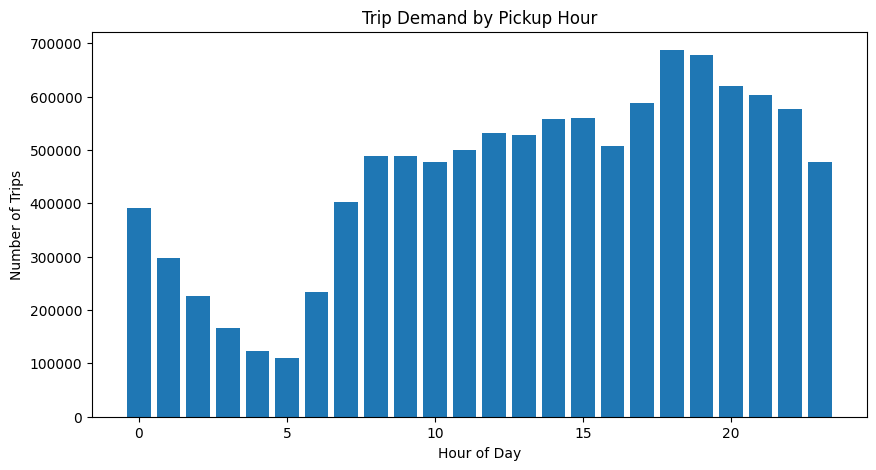

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(hourly_demand['pickup_hour'], hourly_demand['trip_count'])
plt.title('Trip Demand by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

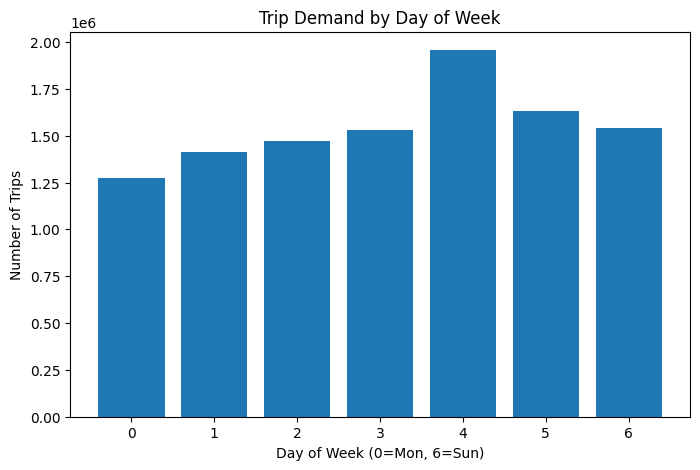

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(weekday_demand['pickup_dayofweek'], weekday_demand['trip_count'])
plt.title('Trip Demand by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Number of Trips')
plt.show()

In [ ]:
hourly_duration = df.groupby('pickup_hour')['trip_duration_min'].mean().reset_index()

In [ ]:
hourly_duration

,pickup_hour,trip_duration_min
0,0,12.561822
1,1,12.145903
2,2,11.915181
3,3,12.029537
4,4,12.522976
5,5,12.082835
6,6,11.402833
7,7,12.348460
8,8,13.538973
9,9,13.474293


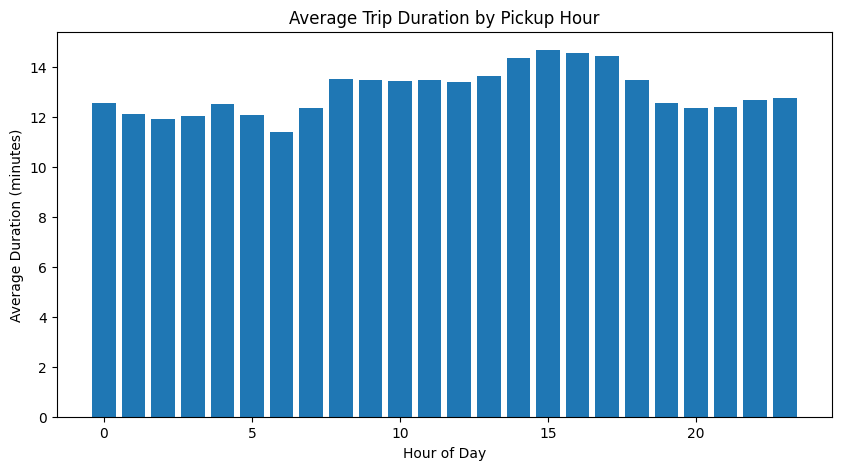

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(hourly_duration['pickup_hour'], hourly_duration['trip_duration_min'])
plt.title('Average Trip Duration by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Duration (minutes)')
plt.show()

In [ ]:
hourly_merged = hourly_demand.merge(hourly_duration, on='pickup_hour')
hourly_merged.sort_values('trip_count', ascending=False).head()

,pickup_hour,trip_count,trip_duration_min
18,18,687311,13.505415
19,19,678479,12.559869
20,20,620123,12.375541
21,21,603799,12.398238
17,17,587148,14.443598


In [ ]:
hourly_merged['efficiency'] = hourly_merged['trip_count'] / hourly_merged['trip_duration_min']
hourly_merged.sort_values('efficiency', ascending=False).head()

,pickup_hour,trip_count,trip_duration_min,efficiency
19,19,678479,12.559869,54019.593304
18,18,687311,13.505415,50891.511984
20,20,620123,12.375541,50108.757978
21,21,603799,12.398238,48700.387516
22,22,577230,12.672164,45551.019557


High efficiency → good marketplace balance
Low efficiency → slow trips/congestion → bad

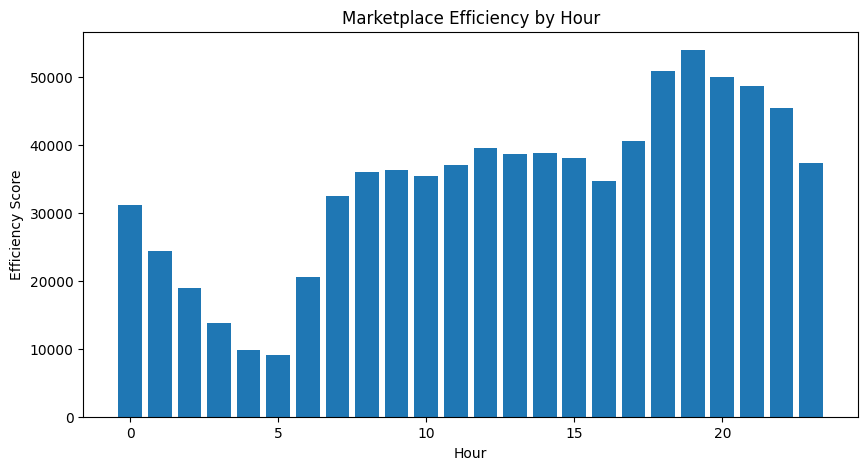

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(hourly_merged['pickup_hour'], hourly_merged['efficiency'])
plt.title('Marketplace Efficiency by Hour')
plt.xlabel('Hour')
plt.ylabel('Efficiency Score')
plt.show()